In [1]:
from pathlib import Path
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
def get_spark():
    return SparkSession.builder \
        .appName('TCC - Testes') \
        .getOrCreate()

spark = get_spark()

In [4]:
base_path = "../data/criminalidade/curated/veiculos_setor_parquet"

df = (
    spark.read
    .option("basePath", base_path)
    .option("mergeSchema", "true")
    .parquet(f"{base_path}/ano_trimestre=*")
)

df_ocorrencias = df.withColumn(
    "ano",
    F.regexp_extract(
        F.col("ano_trimestre"),
        r"(\d{4})",
        1
    ).cast("int")
)

df_ocorrencias = (
    df_ocorrencias
    .filter(
        F.col("ano").cast("int").between(2020, 2025)
    )
)

df_ocorrencias = df_ocorrencias.filter(df_ocorrencias.SJ_CD_SETOR.isNotNull())
# df_ocorrencias.printSchema()
df_ocorrencias.show(5, False)

+------------+--------------------+--------------------+--------------+------+-------+------+----------------------+-------------------+------------------------+-------------------+------------------+---------------+----------------------+-------------------+----------------------+------------+--------------+-----------+----------------+-------------+--------------------+------------------+-----------------+-------+-------------------+---------------------------------+-----------------+-----------------+-----------------+------------+------------------------+------------------+--------------------+--------------+----------+-------------+-----------------+---------------+---------------+-------------------+-----------+-----------------+-----------------+----------------------------+----------------------+-------------------+-------------+--------+--------+-----------+---------------+-----------+---------+----------+-----------------+------------+------------+--------+---------+---------

1560162 - Registros Com Coordenadas 81,6%
1913306 - Total de Registros

In [5]:
df_censo_final = spark.read.parquet('../data/censo/final/processed/setor')
df_censo = df_censo_final.filter(df_censo_final.nm_mun == 'São Paulo')
# df_censo.printSchema()
df_censo.show(5, False)

+---------------+---------+---------+-----------+-----------+-----------+-------+--------------------+-------+---------+---------+----------+-------------+----------------------------------+--------------------------------+----------------------+--------------------+----------------------+-------------------+--------------------------------------------+------------------+------------------+---------------------+-------------------+-----------+----------+--------------------+-------------------+-------------------+----------------------------+---------------------------------------+-----------------------------------------+-------------------------------------------+------------------------------------+-----------------+-----------------+--------------------------+----------------------------+-------------------------+---------------------------+----------------------------+------------------------+----------------------+-----------------------------+
|cd_setor       |cd_dist  |nm_dist 

In [6]:
# ============================================================
# 0. Criar um dataframe de furto e roubo de veículos
# ============================================================

# ============================================================
# 1. Filtrar apenas roubos e furtos de veículos
# ============================================================

df_crimes_filtrado = (
    df_ocorrencias
    .filter(
        (F.col("is_roubo") == "true") |
        (F.col("is_furto") == "true")
    )
    .filter(F.col("SJ_CD_SETOR").isNotNull())
)

# ============================================================
# 2. Agregar crimes por setor, ano e trimestre
# ============================================================

df_crimes_agregado = (
    df_crimes_filtrado
    .groupBy(
        F.col("SJ_CD_SETOR").alias("cd_setor"),
        F.col("ano").cast("int").alias("ano"),
        F.col("trimestre_particao").alias("trimestre")
    )
    .agg(
        F.count("*").alias("qt_crimes"),
        F.sum(F.when(F.col("is_roubo") == "true", 1).otherwise(0)).alias("qt_roubos"),
        F.sum(F.when(F.col("is_furto") == "true", 1).otherwise(0)).alias("qt_furtos")
    )
)

# ============================================================
# 3. Cruzar crimes agregados com dados do Censo
# ============================================================

df_analise = (
    df_crimes_agregado
    .join(
        df_censo,
        on="cd_setor",
        how="left"
    )
)

df_analise = df_analise.filter(F.col("nm_mun") == "São Paulo")

# ============================================================
# 4. Criar taxas padronizadas
# ============================================================

df_analise_taxa_crime = (
    df_analise
    .withColumn(
        "tx_crimes_1000_hab",
        F.when(
            F.col("qt_pessoas") > 0,
            (F.col("qt_crimes") / F.col("qt_pessoas")) * 1000
        )
    )
    .withColumn(
        "tx_roubos_1000_hab",
        F.when(
            F.col("qt_pessoas") > 0,
            (F.col("qt_roubos") / F.col("qt_pessoas")) * 1000
        )
    )
    .withColumn(
        "tx_furtos_1000_hab",
        F.when(
            F.col("qt_pessoas") > 0,
            (F.col("qt_furtos") / F.col("qt_pessoas")) * 1000
        )
    )
    .withColumn(
        "tx_crimes_km2",
        F.col("qt_crimes") / F.col("area_km2")
    )
)

df_analise_taxa_crime = df_analise_taxa_crime.filter(F.col("cd_setor").isNotNull())

# ============================================================
# 5. Validar resultado
# ============================================================
# df_analise_taxa_crime = df_analise_taxa_crime.filter(df_analise_taxa_crime.qt_pessoas.isNotNull())
# df_analise_taxa_crime.printSchema()

df_analise_taxa_crime.select(
    "cd_setor",
    "ano",
    "trimestre",
    "qt_crimes",
    "qt_roubos",
    "qt_furtos",
    "qt_pessoas",
    "area_km2",
    "tx_crimes_1000_hab",
    "tx_crimes_km2",
    "indice_infraestrutura_urbana",
    "log_renda_media",
    "densidade_populacional"
).show(5, truncate=False)

+---------------+----+---------+---------+---------+---------+----------+---------+------------------+------------------+----------------------------+------------------+----------------------+
|cd_setor       |ano |trimestre|qt_crimes|qt_roubos|qt_furtos|qt_pessoas|area_km2 |tx_crimes_1000_hab|tx_crimes_km2     |indice_infraestrutura_urbana|log_renda_media   |densidade_populacional|
+---------------+----+---------+---------+---------+---------+----------+---------+------------------+------------------+----------------------------+------------------+----------------------+
|355030876000170|2022|3        |3        |0        |3        |327       |0.0528353|9.174311926605505 |56.780220799351945|0.7586666666666667          |7.789818888946994 |6189.044067129362     |
|355030862000224|2022|3        |2        |0        |2        |353       |0.0191802|5.6657223796034   |104.27419943483383|0.9553376906318083          |9.798885082822196 |18404.39620024817     |
|355030820000151|2022|3        |4  

+-------+-------------------+
|summary|tx_crimes_1000_hab |
+-------+-------------------+
|count  |158361             |
|mean   |10.146068023831749 |
|stddev |88.98763005671391  |
|min    |0.45024763619990993|
|25%    |1.9305019305019306 |
|50%    |3.003003003003003  |
|75%    |5.291005291005291  |
|max    |6750.0             |
+-------+-------------------+

P25: 1.93
P50: 3.00
P75: 5.29
P90: 10.07
P95: 16.39
P99: 82.19


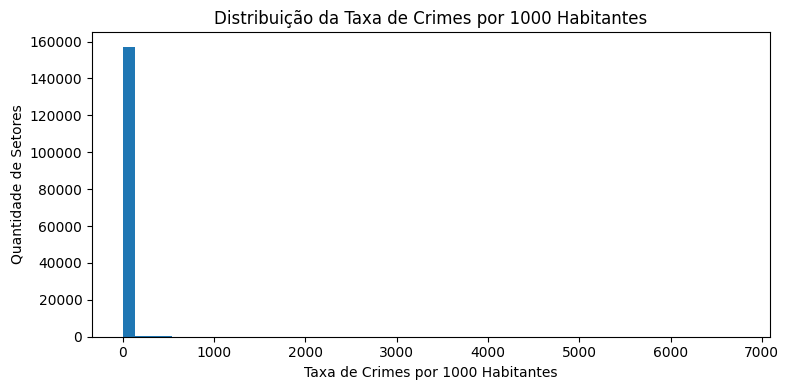

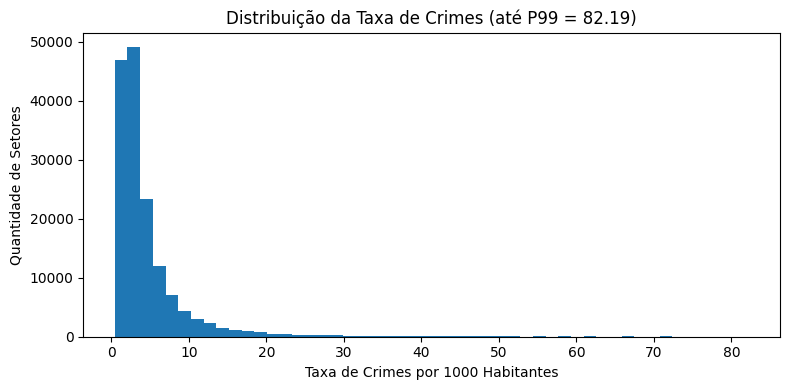

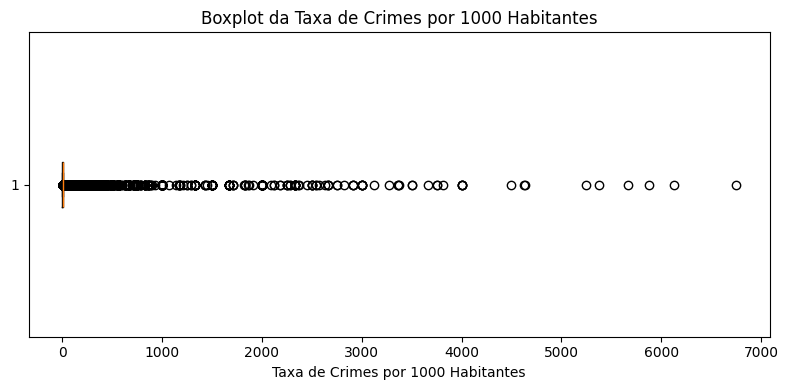

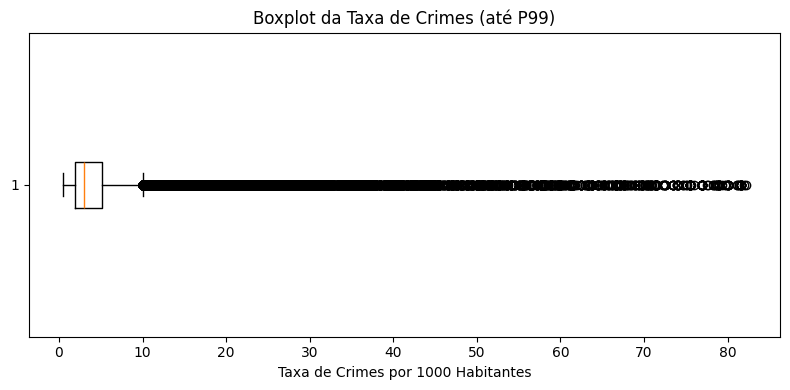

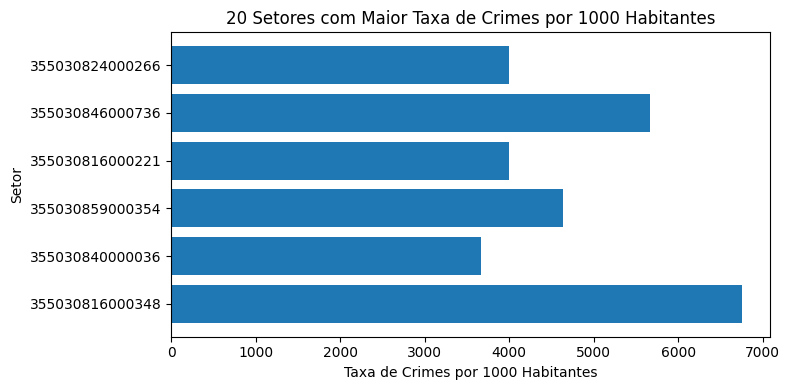

In [7]:
# ============================================================
# 6. Visualização dos Resultados
# ============================================================

# Descritivas
df_analise_taxa_crime.select(
    "tx_crimes_1000_hab"
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
).show(truncate=False)

# Percentis
percentis = df_analise_taxa_crime.approxQuantile(
    "tx_crimes_1000_hab",
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    0.001
)

for nome, valor in zip(
    ["P25", "P50", "P75", "P90", "P95", "P99"],
    percentis
):
    print(f"{nome}: {valor:.2f}")

# Histograma
pdf_hist = (
    df_analise_taxa_crime
    .select("tx_crimes_1000_hab")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(8,4))

plt.hist(
    pdf_hist["tx_crimes_1000_hab"],
    bins=50
)

plt.title("Distribuição da Taxa de Crimes por 1000 Habitantes")
plt.xlabel("Taxa de Crimes por 1000 Habitantes")
plt.ylabel("Quantidade de Setores")

plt.tight_layout()
plt.show()

# Histograma Truncado P99
p99 = percentis[-1]

pdf_hist_p99 = (
    pdf_hist[
        pdf_hist["tx_crimes_1000_hab"] <= p99
    ]
)

plt.figure(figsize=(8,4))

plt.hist(
    pdf_hist_p99["tx_crimes_1000_hab"],
    bins=50
)

plt.title(
    f"Distribuição da Taxa de Crimes (até P99 = {p99:.2f})"
)

plt.xlabel("Taxa de Crimes por 1000 Habitantes")
plt.ylabel("Quantidade de Setores")

plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(8,4))

plt.boxplot(
    pdf_hist["tx_crimes_1000_hab"],
    vert=False
)

plt.title(
    "Boxplot da Taxa de Crimes por 1000 Habitantes"
)

plt.xlabel("Taxa de Crimes por 1000 Habitantes")

plt.tight_layout()
plt.show()

# Boxplot Truncado P99
plt.figure(figsize=(8,4))

plt.boxplot(
    pdf_hist_p99["tx_crimes_1000_hab"],
    vert=False
)

plt.title(
    "Boxplot da Taxa de Crimes (até P99)"
)

plt.xlabel("Taxa de Crimes por 1000 Habitantes")

plt.tight_layout()
plt.show()

# Top 20 Setores mais Críticos
df_top20_setores_criticos = (
    df_analise_taxa_crime
    .orderBy(
        F.col("tx_crimes_1000_hab").desc()
    )
    .select(
        "cd_setor",
        "nm_dist",
        "qt_pessoas",
        "qt_crimes",
        "tx_crimes_1000_hab"
    )
    .limit(20)
)

# df_top20_setores_criticos.show(
#     truncate=False
# )

pdf_top20 = (
    df_top20_setores_criticos
    .toPandas()
)

pdf_top20 = pdf_top20.sort_values(
    "tx_crimes_1000_hab"
)

plt.figure(figsize=(8,4))

plt.barh(
    pdf_top20["cd_setor"].astype(str),
    pdf_top20["tx_crimes_1000_hab"]
)

plt.title(
    "20 Setores com Maior Taxa de Crimes por 1000 Habitantes"
)

plt.xlabel(
    "Taxa de Crimes por 1000 Habitantes"
)

plt.ylabel("Setor")

plt.tight_layout()
plt.show()

## Análise Exploratória da Taxa de Crimes por 1000 Habitantes

Como etapa inicial da análise, foi investigada a distribuição da variável **taxa de crimes por 1000 habitantes** (`tx_crimes_1000_hab`), utilizada como principal indicador de criminalidade nos setores censitários.

A base analisada contém **156.713 observações** de setor censitário/trimestre. A taxa média observada foi de **9,94 crimes por 1000 habitantes**, enquanto a mediana foi de apenas **2,99 crimes por 1000 habitantes**, indicando uma distribuição fortemente assimétrica à direita.

As estatísticas descritivas mostram que:

| Estatística | Valor |
|------------|---------|
| Média | 10,15 |
| Mediana (P50) | 3,00 |
| P75 | 5,29 |
| P90 | 10,07 |
| P95 | 16,39 |
| P99 | 82,19 |
| Máximo | 6750,00 |

Os histogramas evidenciam que a maior parte dos setores apresenta taxas relativamente baixas de criminalidade, concentradas abaixo de 10 crimes por 1000 habitantes. Entretanto, existe uma pequena quantidade de setores com valores extremamente elevados, formando uma longa cauda à direita na distribuição.

Os boxplots reforçam a presença de grande quantidade de valores extremos (outliers), característica comum em fenômenos criminais espacialmente concentrados. Observa-se que 99% das observações possuem taxa inferior a aproximadamente 77 crimes por 1000 habitantes, enquanto o valor máximo registrado alcança 6750 crimes por 1000 habitantes.

Esse comportamento sugere que a criminalidade não está distribuída de forma homogênea entre os setores censitários, mas sim concentrada em um número reduzido de áreas com incidência muito superior à média do município.

Os resultados também indicam a necessidade de investigar os setores responsáveis pelos valores extremos, avaliando aspectos como população residente, quantidade absoluta de ocorrências e características territoriais, uma vez que taxas muito elevadas podem estar associadas a setores com população reduzida, o que tende a inflar indicadores padronizados por habitante.

De modo geral, a análise exploratória confirma a existência de forte heterogeneidade espacial da criminalidade, justificando a utilização de técnicas adicionais de análise estatística e geoespacial nas próximas etapas do estudo.

In [8]:
# Identificando setores extremos

df_top25_taxas = (
    df_analise_taxa_crime
    .select(
        "cd_setor",
        "nm_dist",
        "qt_pessoas",
        "area_km2",
        "qt_crimes",
        "qt_roubos",
        "qt_furtos",
        "tx_crimes_1000_hab"
    )
    .orderBy(
        F.col("tx_crimes_1000_hab").desc()
    )
    .limit(50)
)

df_top25_taxas.show(
    n=25,
    truncate=False
)

# Distribuição da população 
df_analise_taxa_crime.select(
    "qt_pessoas"
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
).show(truncate=False)

## Correção devido a grande cauda a direita
df_analise_taxa_crime = (
    df_analise_taxa_crime
    .withColumn(
        "log_tx_crimes_1000_hab",
        F.log1p(
            F.col("tx_crimes_1000_hab")
        )
    )
)
## Criação de uma base com filtro populacional
df_analise_taxa_crime_filtrado = (
    df_analise_taxa_crime
    .filter(F.col("qt_pessoas") >= 50)
)

+---------------+---------------+----------+---------+---------+---------+---------+------------------+
|cd_setor       |nm_dist        |qt_pessoas|area_km2 |qt_crimes|qt_roubos|qt_furtos|tx_crimes_1000_hab|
+---------------+---------------+----------+---------+---------+---------+---------+------------------+
|355030816000348|Campo Grande   |8         |0.784018 |54       |15       |39       |6750.0            |
|355030816000348|Campo Grande   |8         |0.784018 |49       |10       |39       |6125.0            |
|355030816000348|Campo Grande   |8         |0.784018 |47       |17       |30       |5875.0            |
|355030846000736|Jardim São Luís|3         |0.7550655|17       |10       |7        |5666.666666666667 |
|355030816000348|Campo Grande   |8         |0.784018 |43       |13       |30       |5375.0            |
|355030816000348|Campo Grande   |8         |0.784018 |42       |8        |34       |5250.0            |
|355030859000354|Penha          |11        |0.3217786|51       |

## Avaliação dos Outliers Populacionais e Definição da Base Analítica

A análise dos setores com maiores taxas de crimes por 1000 habitantes revelou que os valores extremos observados não estão necessariamente associados aos maiores volumes absolutos de criminalidade, mas sim a setores censitários com população residente muito reduzida.

Foram identificados setores com apenas 1, 3, 8 ou 11 habitantes que registraram múltiplas ocorrências criminais ao longo do período analisado. Como a taxa é calculada por 1000 habitantes, pequenas quantidades de crimes em populações extremamente baixas produzem indicadores artificialmente elevados. Por exemplo, um setor com 8 habitantes e 54 ocorrências apresenta uma taxa de 6750 crimes por 1000 habitantes.

A análise da distribuição populacional mostrou que esses casos são exceções dentro da base. A população mediana dos setores é de aproximadamente 462 habitantes, com 75% dos setores possuindo pelo menos 316 habitantes e no máximo 615 habitantes. Dessa forma, os valores extremos decorrem de um número muito reduzido de setores atípicos e não representam o comportamento predominante da cidade.

Por esse motivo, optou-se por manter a base completa para análises espaciais e representação cartográfica, preservando todas as observações originais. Entretanto, para análises estatísticas inferenciais, correlações e regressões, recomenda-se a criação de uma base analítica filtrada contendo apenas setores com população mínima de referência (por exemplo, 50 ou 100 habitantes).

Essa estratégia reduz a influência desproporcional de setores com população extremamente baixa sobre coeficientes de correlação, modelos de regressão e medidas de tendência central, aumentando a robustez estatística dos resultados sem comprometer a integridade da base original.

Dessa forma, o estudo passa a trabalhar com duas estruturas complementares:

- **Base completa (`df_analise_taxa_crime`)**: utilizada para mapas, estatísticas descritivas gerais e análise espacial;
- **Base analítica filtrada (`df_analise_taxa_crime_filtrado`)**: utilizada para correlações, regressões e demais análises estatísticas que exigem maior estabilidade dos indicadores.

Essa abordagem permite preservar a realidade espacial observada nos dados ao mesmo tempo em que minimiza possíveis distorções decorrentes de setores censitários com população muito reduzida.

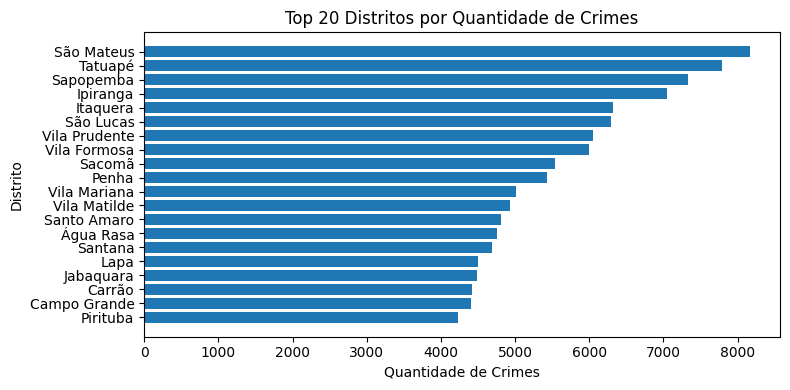

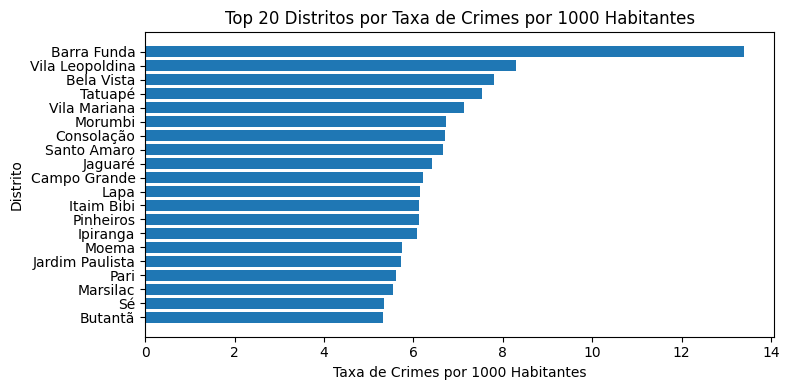

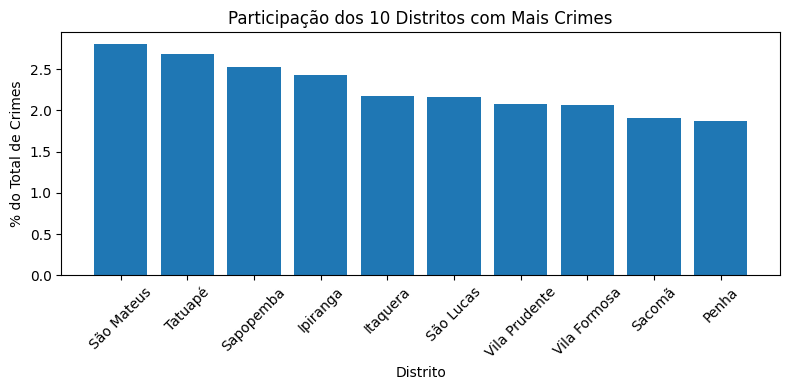

In [9]:
df_crimes_distrito = (
    df_analise_taxa_crime
    .filter(F.col("nm_dist").isNotNull())
    .groupBy("nm_dist")
    .agg(
        F.sum("qt_crimes").alias("qt_crimes"),
        F.sum("qt_roubos").alias("qt_roubos"),
        F.sum("qt_furtos").alias("qt_furtos")
    )
    .orderBy(F.col("qt_crimes").desc())
)

# df_crimes_distrito.show(
#     20,
#     truncate=False
# )

## Gráfico
pdf_top20_crimes = (
    df_crimes_distrito
    .limit(20)
    .toPandas()
)

pdf_top20_crimes = pdf_top20_crimes.sort_values(
    "qt_crimes"
)

plt.figure(figsize=(8,4))

plt.barh(
    pdf_top20_crimes["nm_dist"],
    pdf_top20_crimes["qt_crimes"]
)

plt.title(
    "Top 20 Distritos por Quantidade de Crimes"
)

plt.xlabel("Quantidade de Crimes")
plt.ylabel("Distrito")

plt.tight_layout()
# plt.show()

# Taxa de Crimes por Distrito
df_taxa_distrito = (
    df_analise_taxa_crime
    .groupBy("nm_dist")
    .agg(
        F.sum("qt_crimes").alias("qt_crimes"),
        F.sum("qt_pessoas").alias("qt_pessoas")
    )
    .withColumn(
        "tx_crimes_1000_hab",
        (F.col("qt_crimes") / F.col("qt_pessoas")) * 1000
    )
    .orderBy(
        F.col("tx_crimes_1000_hab").desc()
    )
)

# df_taxa_distrito.show(
#     20,
#     truncate=False
# )

pdf_top20_taxa = (
    df_taxa_distrito
    .limit(20)
    .toPandas()
)

pdf_top20_taxa = pdf_top20_taxa.sort_values(
    "tx_crimes_1000_hab"
)

plt.figure(figsize=(8,4))

plt.barh(
    pdf_top20_taxa["nm_dist"],
    pdf_top20_taxa["tx_crimes_1000_hab"]
)

plt.title(
    "Top 20 Distritos por Taxa de Crimes por 1000 Habitantes"
)

plt.xlabel("Taxa de Crimes por 1000 Habitantes")
plt.ylabel("Distrito")

plt.tight_layout()
# plt.show()


total_crimes = (
    df_crimes_distrito
    .agg(
        F.sum("qt_crimes")
    )
    .first()[0]
)

df_participacao_distrito = (
    df_crimes_distrito
    .withColumn(
        "participacao_pct",
        (
            F.col("qt_crimes") /
            F.lit(total_crimes)
        ) * 100
    )
    .orderBy(
        F.col("participacao_pct").desc()
    )
)

# df_participacao_distrito.show(
#     20,
#     truncate=False
# )

pdf_participacao = (
    df_participacao_distrito
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(8,4))

plt.bar(
    pdf_participacao["nm_dist"],
    pdf_participacao["participacao_pct"]
)

plt.title(
    "Participação dos 10 Distritos com Mais Crimes"
)

plt.ylabel("% do Total de Crimes")
plt.xlabel("Distrito")

plt.xticks(rotation=45)

plt.tight_layout()
# plt.show()

## Análise Distrital da Criminalidade

A análise agregada por distrito permitiu identificar diferenças relevantes entre a distribuição absoluta e relativa dos roubos e furtos de veículos no município de São Paulo.

Os maiores volumes de ocorrências foram observados nos distritos de São Mateus (8.163 crimes), Tatuapé (7.792), Sapopemba (7.333), Ipiranga (7.050) e Itaquera (6.318). Em grande parte desses distritos predominam os furtos de veículos, que representam a maioria das ocorrências registradas.

Quando considerada a taxa de crimes por 1000 habitantes, observa-se um padrão distinto. Os maiores valores foram encontrados na Barra Funda (13,39 crimes por 1000 habitantes), Vila Leopoldina (8,30), Bela Vista (7,81), Tatuapé (7,54) e Vila Mariana (7,13). Esse resultado demonstra que distritos com maior volume absoluto nem sempre apresentam as maiores taxas relativas de criminalidade.

Os distritos com maiores taxas concentram importantes polos comerciais, empresariais e de serviços da cidade, caracterizados por elevada circulação de pessoas e veículos. Esse padrão sugere que a dinâmica urbana e a intensidade dos fluxos cotidianos podem exercer influência relevante sobre a incidência de roubos e furtos de veículos.

A análise também revelou que nenhum distrito concentra isoladamente parcela expressiva da criminalidade municipal. Os distritos mais representativos respondem individualmente por aproximadamente 2% a 3% do total de ocorrências registradas, indicando uma distribuição relativamente dispersa dos crimes ao longo do território urbano.

Esses resultados reforçam a importância da utilização simultânea de indicadores absolutos e relativos para compreender a distribuição espacial da criminalidade, além de justificarem análises posteriores envolvendo características socioeconômicas, infraestrutura urbana e padrões espaciais de concentração criminal.

+----+---------+
| ano|qt_crimes|
+----+---------+
|2020|    37868|
|2021|    42624|
|2022|    52324|
|2023|    56759|
|2024|    55427|
|2025|    45833|
+----+---------+



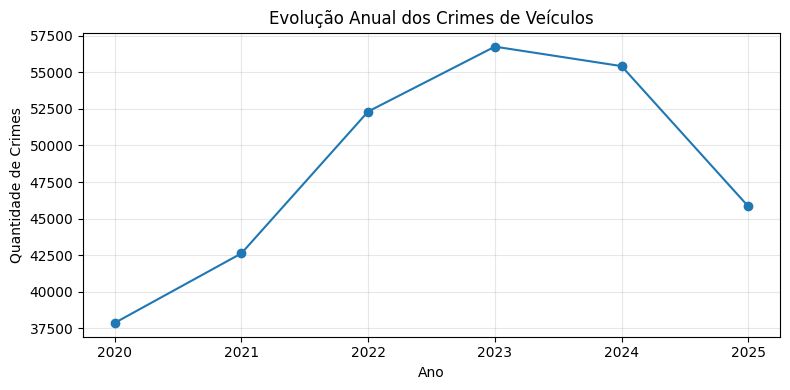

In [10]:
df_crimes_ano = (
    df_analise_taxa_crime
    .groupBy("ano")
    .agg(
        F.sum("qt_crimes").alias("qt_crimes")
    )
    .orderBy("ano")
)
df_crimes_ano.show()
pdf_crimes_ano = df_crimes_ano.toPandas()

plt.figure(figsize=(8,4))

plt.plot(
    pdf_crimes_ano["ano"],
    pdf_crimes_ano["qt_crimes"],
    marker="o"
)

plt.title("Evolução Anual dos Crimes de Veículos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Crimes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Limitações e Considerações Metodológicas sobre os Dados Criminais

Os dados criminais utilizados neste estudo foram obtidos a partir da base pública georreferenciada disponibilizada pela Secretaria da Segurança Pública do Estado de São Paulo (SSP-SP). Diferentemente das estatísticas criminais oficiais consolidadas divulgadas anualmente pela Secretaria, essa base disponibiliza informações detalhadas sobre cada registro de ocorrência, incluindo coordenadas geográficas e identificadores espaciais que permitem a associação dos eventos criminais aos setores censitários do município de São Paulo.

A utilização dessa base foi necessária para viabilizar a análise geoespacial proposta nesta pesquisa, uma vez que as estatísticas oficiais agregadas não disponibilizam latitude, longitude ou outras informações espaciais suficientes para a integração com os dados censitários e de infraestrutura urbana.

Entretanto, a própria SSP-SP informa que os dados disponibilizados são extraídos diretamente dos sistemas operacionais de registro de ocorrências, principalmente do Registro Digital de Ocorrências (RDO) e do Sistema de Polícia Judiciária (SPJ), não constituindo as estatísticas criminais oficiais do Estado. Segundo a documentação oficial, os sistemas e seus respectivos campos estão sujeitos a atualizações, alterações de preenchimento e aperfeiçoamentos metodológicos ao longo do tempo, podendo impactar consultas e extrações realizadas pelos usuários.

Outro aspecto relevante refere-se à estrutura dos registros disponibilizados. Conforme informado pela SSP-SP, uma mesma ocorrência pode gerar múltiplos registros na base, uma vez que cada linha pode representar pessoas, objetos ou naturezas criminais distintas associadas ao mesmo boletim de ocorrência. Dessa forma, procedimentos de tratamento e deduplicação foram aplicados durante a etapa de preparação dos dados, buscando reduzir possíveis duplicidades e aproximar os registros da contagem efetiva de ocorrências criminais.

Em razão dessas características, os quantitativos obtidos neste trabalho podem apresentar diferenças em relação às estatísticas criminais oficiais publicadas pela SSP-SP. Tais divergências são esperadas e decorrem tanto das particularidades da base georreferenciada utilizada quanto dos processos de consolidação empregados pela Secretaria na produção dos indicadores oficiais.

Apesar dessas limitações, a base utilizada é considerada adequada para os objetivos desta pesquisa. O foco do estudo não consiste na reprodução exata das estatísticas oficiais de criminalidade, mas na investigação dos padrões espaciais dos roubos e furtos de veículos e de sua relação com características socioeconômicas e de infraestrutura urbana em nível de setor censitário. Nesse contexto, a disponibilidade de informações espaciais detalhadas torna essa base a fonte mais apropriada para a realização das análises geoespaciais propostas, mesmo que seus totais absolutos possam divergir dos números oficiais consolidados.

Por fim, o período analisado foi delimitado entre os anos de 2020 e 2025. Essa escolha visa concentrar a investigação em um intervalo temporal recente e compatível com as informações censitárias utilizadas no estudo, além de reduzir potenciais inconsistências decorrentes de alterações históricas nos sistemas de registro e georreferenciamento das ocorrências policiais.